In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [25]:
# data yuklandi
data = pd.read_csv('coding_challenge_dataset.csv')

In [26]:
data.head()

,client_id,age,income,loan_amount,loan_term,credit_score,employment_years,married,num_children,education_level,default
0,1,56,10767500,10685684,40,740,22,0,4,3,0
1,2,46,22976807,15321905,33,540,21,1,1,3,0
2,3,32,24277761,18958103,19,453,1,1,0,1,0
3,4,60,10291923,27973434,15,395,22,0,4,1,1
4,5,25,21931456,22217066,21,593,10,0,1,2,0


In [27]:
matrix_corr = data.corr(numeric_only=True)
matrix_corr

,client_id,age,income,loan_amount,loan_term,credit_score,employment_years,married,num_children,education_level,default
client_id,1.000000,-0.024857,-0.036880,0.027146,0.025545,-0.006350,-0.034860,-0.057590,0.054986,-0.045563,0.080620
age,-0.024857,1.000000,-0.056786,0.026762,0.025951,0.039742,0.030504,-0.014112,0.013194,0.001837,0.040146
income,-0.036880,-0.056786,1.000000,0.015411,-0.056437,-0.042353,0.003240,-0.030011,-0.010022,-0.022651,-0.616677
loan_amount,0.027146,0.026762,0.015411,1.000000,0.041659,0.060019,-0.009818,0.026430,-0.042497,0.004351,0.433778
loan_term,0.025545,0.025951,-0.056437,0.041659,1.000000,0.014753,-0.055969,0.023536,-0.009583,-0.028669,0.077168
credit_score,-0.006350,0.039742,-0.042353,0.060019,0.014753,1.000000,-0.003953,0.022338,0.001866,-0.006278,-0.067962
employment_years,-0.034860,0.030504,0.003240,-0.009818,-0.055969,-0.003953,1.000000,-0.016934,-0.018770,0.026496,-0.079351
married,-0.057590,-0.014112,-0.030011,0.026430,0.023536,0.022338,-0.016934,1.000000,0.010697,-0.001393,0.041910
num_children,0.054986,0.013194,-0.010022,-0.042497,-0.009583,0.001866,-0.018770,0.010697,1.000000,0.029536,-0.037380
education_level,-0.045563,0.001837,-0.022651,0.004351,-0.028669,-0.006278,0.026496,-0.001393,0.029536,1.000000,-0.020347


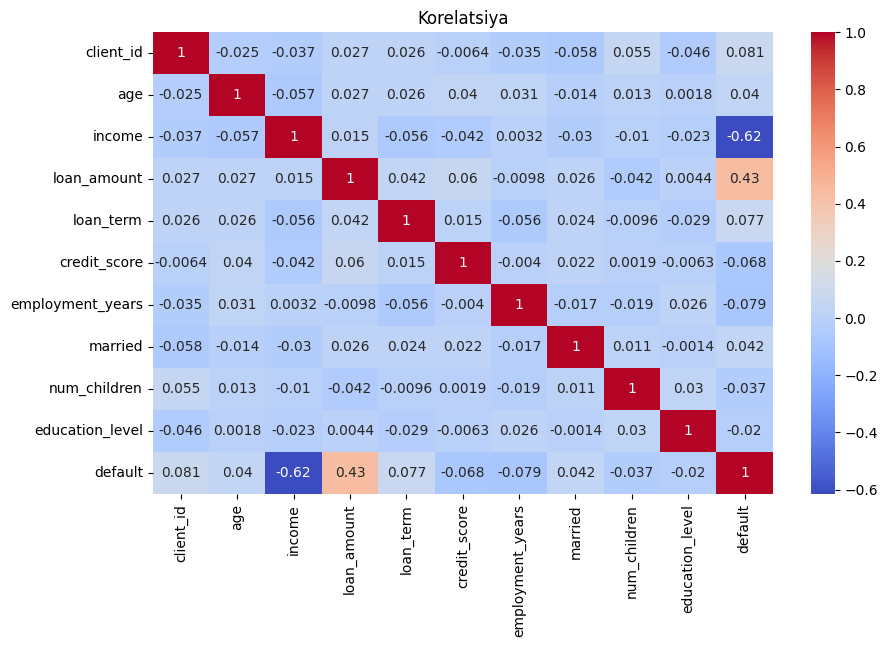

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(matrix_corr,annot=True,cmap='coolwarm')
plt.title("Korelatsiya")
plt.show()

TypeError: title() missing 1 required positional argument: 'label'

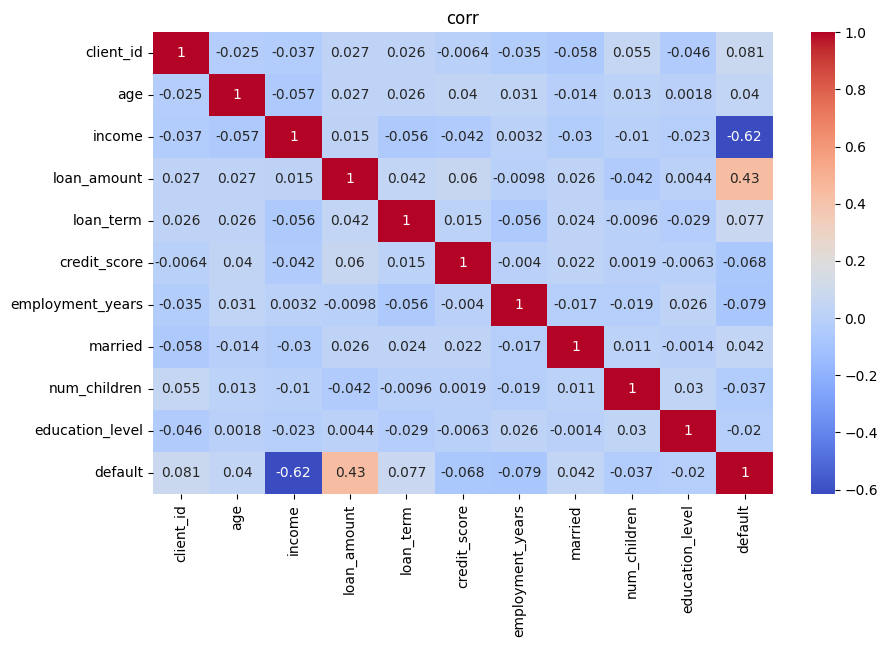

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(matrix_corr,annot=True,cmap="coolwarm")
plt.title("corr")
plt.title()

In [53]:
feature_colums = [
    "age","income","loan_amount","loan_term",
    "credit_score","employment_years","num_children",
    "education_level"
]

In [54]:
X = data[feature_colums]
Y = data["default"]

In [48]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [55]:
print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

x_train:  (800, 7)
x_test:  (200, 7)
y_train:  (800,)
y_test:  (200,)


In [56]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

In [57]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
lgb_pred = lgb_model.predict_proba(x_test)[:,1]

lgb_aus = roc_auc_score(y_test,lgb_pred)

[LightGBM] [Info] Number of positive: 250, number of negative: 550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [58]:
print("LightGBM AUC: ",lgb_aus * 100,"%")

LightGBM AUC:  99.66666666666667 %


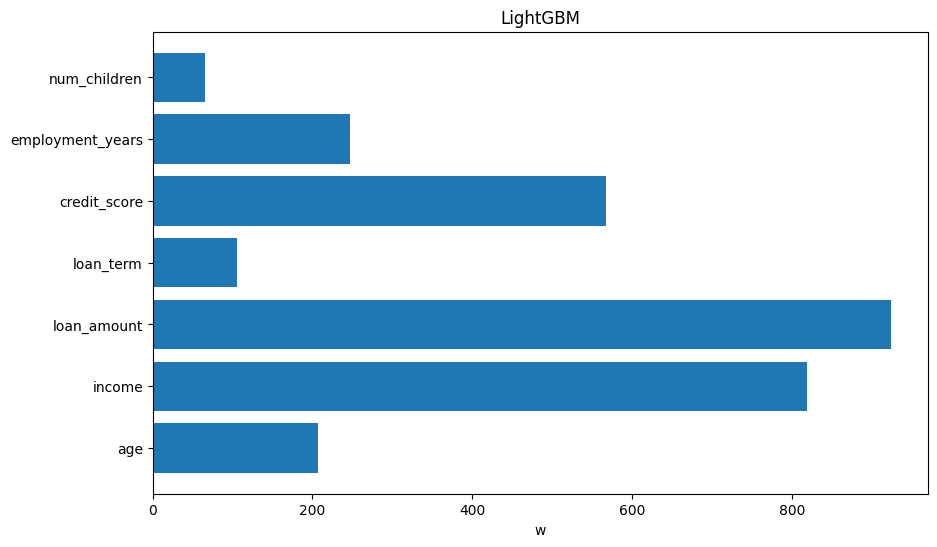

In [59]:
w = lgb_model.feature_importances_
s = x_train.columns


plt.figure(figsize=(10,6))
plt.barh(s,w)
plt.xlabel("w")
plt.title("LightGBM")
plt.show()

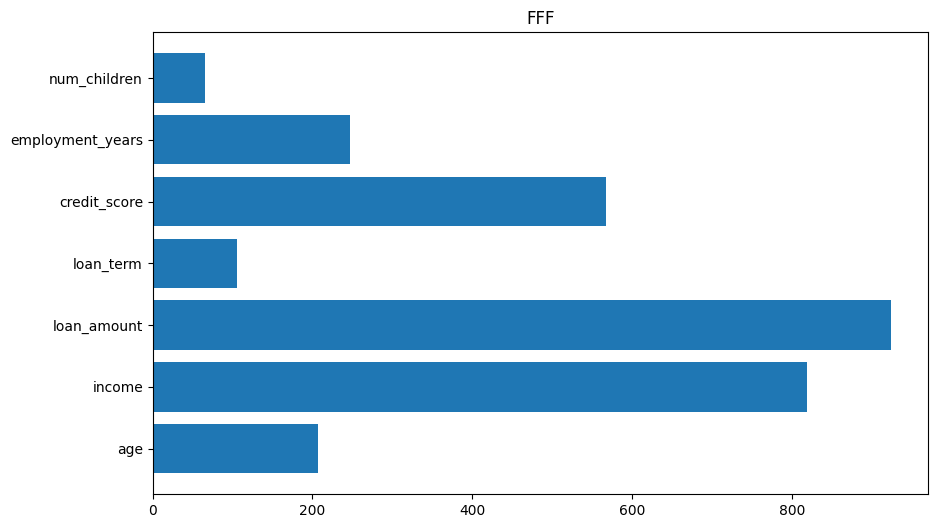

In [60]:
w = lgb_model.feature_importances_
s = x_train.columns

plt.figure(figsize=(10,6))
plt.barh(s,w)
plt.title("FFF")
plt.show()